In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Load CV embeddings

In [2]:
cv_rnn = np.load("/content/cv_embeddings_RNN.npy")
cv_gru = np.load("/content/cv_embeddings_gru.npy")
cv_lstm = np.load("/content/cv_embeddings_lstm.npy")
cv_bert = np.load("/content/cv_embeddings_bert.npy")

# Load Job embeddings

In [3]:
job_rnn = np.load("/content/job_embeddings_RNN.npy")
job_gru = np.load("/content/job_embeddings_gru.npy")
job_lstm = np.load("/content/job_embeddings_lstm.npy")
job_bert = np.load("/content/job_embeddings_bert.npy")

## Normalize

In [4]:
from sklearn.preprocessing import normalize

cv_rnn = normalize(cv_rnn)
cv_gru = normalize(cv_gru)
cv_lstm = normalize(cv_lstm)
cv_bert = normalize(cv_bert)

job_rnn = normalize(job_rnn)
job_gru = normalize(job_gru)
job_lstm = normalize(job_lstm)
job_bert = normalize(job_bert)

# Fusion_CV

In [6]:
print("CV RNN:", cv_rnn.shape)
print("CV GRU:", cv_gru.shape)
print("CV LSTM:", cv_lstm.shape)
print("CV BERT:", cv_bert.shape)

print("-"*40)

print("JOB RNN:", job_rnn.shape)
print("JOB GRU:", job_gru.shape)
print("JOB LSTM:", job_lstm.shape)
print("JOB BERT:", job_bert.shape)

CV RNN: (500, 64)
CV GRU: (1065, 128)
CV LSTM: (1065, 64)
CV BERT: (3500, 384)
----------------------------------------
JOB RNN: (500, 64)
JOB GRU: (3685, 128)
JOB LSTM: (3685, 64)
JOB BERT: (3685, 384)


In [7]:
cv_bert = cv_bert[:1065]
job_bert = job_bert[:3685]

In [8]:
cv_gru = cv_gru[:1065]
cv_lstm = cv_lstm[:1065]
cv_bert = cv_bert[:1065]

In [9]:
from sklearn.preprocessing import normalize

cv_gru = normalize(cv_gru)
cv_lstm = normalize(cv_lstm)
cv_bert = normalize(cv_bert)

job_gru = normalize(job_gru)
job_lstm = normalize(job_lstm)
job_bert = normalize(job_bert)

In [10]:
cv_fusion = np.concatenate([
    cv_gru,
    cv_lstm,
    cv_bert
], axis=1)

## Fusion_jops

In [11]:
job_fusion = np.concatenate([
    job_gru,
    job_lstm,
    job_bert
], axis=1)

In [12]:
print(cv_fusion.shape)
print(job_fusion.shape)

(1065, 576)
(3685, 576)


# similarity

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    cv_fusion,
    job_fusion
)

# recommendation

In [14]:
top_jobs = np.argsort(similarity_matrix[0])[::-1][:5]

print(top_jobs)

[2961 1788 3384 2550 2488]


In [17]:
import pandas as pd

jobs_data = pd.read_csv("/content/final_jobs_dataset.csv")

In [18]:
for idx in top_jobs:
    print(jobs_data.iloc[idx]['job_title'])

data analyst
data analyst- remote
system/data analyst
big data/machine learning engineer - sr
director of data science


In [21]:
seen = set()
final_jobs = []

for idx in top_jobs:
    title = jobs_data.iloc[idx]['job_title']

    if title not in seen:
        final_jobs.append(title)
        seen.add(title)

In [22]:
for i, title in enumerate(final_jobs):
    print(f"{i+1}. {title}")

1. data analyst
2. data analyst- remote
3. system/data analyst
4. big data/machine learning engineer - sr
5. director of data science


In [23]:
for idx in top_jobs:
    print(
        jobs_data.iloc[idx]['job_title'],
        similarity_matrix[0][idx]
    )

data analyst 0.5271358
data analyst- remote 0.52701384
system/data analyst 0.5256441
big data/machine learning engineer - sr 0.5125719
director of data science 0.5078535


In [24]:
scores = similarity_matrix[0]

scores = (scores - scores.min()) / (scores.max() - scores.min())

In [25]:
import numpy as np

exp_scores = np.exp(scores)
soft_scores = exp_scores / np.sum(exp_scores)

In [26]:
for idx in top_jobs:
    print(
        jobs_data.iloc[idx]['job_title'],
        round(similarity_matrix[0][idx]*100, 2), "%"
    )

data analyst 52.71 %
data analyst- remote 52.7 %
system/data analyst 52.56 %
big data/machine learning engineer - sr 51.26 %
director of data science 50.79 %


# Calibration

In [36]:
scores = np.array(final_scores)

calibrated_scores = (scores - scores.min()) / (scores.max() - scores.min())

In [37]:
import numpy as np

exp_scores = np.exp(scores)
calibrated_scores = exp_scores / np.sum(exp_scores)

# _____________________________________

# Load Image Embeddings

In [38]:
import numpy as np

cnn_img = np.load("/content/cnn_image_embeddings.npy")
vit_img = np.load("/content/vit_image_embeddings.npy")

print("CNN:", cnn_img.shape)
print("ViT:", vit_img.shape)

CNN: (6451, 128)
ViT: (8067, 768)


In [39]:
min_len = min(len(cnn_img), len(vit_img))

cnn_img = cnn_img[:min_len]
vit_img = vit_img[:min_len]

In [41]:
from sklearn.decomposition import PCA

pca_cnn = PCA(n_components=128)
pca_vit = PCA(n_components=128)

cnn_proj = pca_cnn.fit_transform(cnn_img)
vit_proj = pca_vit.fit_transform(vit_img)

In [42]:
pca_dim = 64

pca_cnn = PCA(n_components=pca_dim)
pca_vit = PCA(n_components=pca_dim)

In [43]:
from sklearn.preprocessing import normalize

cnn_proj = normalize(cnn_proj)
vit_proj = normalize(vit_proj)

In [44]:
image_fusion = np.concatenate([cnn_proj, vit_proj], axis=1)

print(image_fusion.shape)

(6451, 256)


# ________________________________________________

# FINAL RECOMMENDATION ENGINE

# _______________________________________________

In [46]:
np.save("cv_fusion.npy", cv_fusion)
np.save("job_fusion.npy", job_fusion)

In [50]:
np.save("image_fusion.npy", image_fusion)

# FINAL FUSIONS

In [51]:
import numpy as np

# TEXT (FINAL)
cv_text = np.load("cv_fusion.npy")
job_text = np.load("job_fusion.npy")

# IMAGE (FINAL)
image_emb = np.load("image_fusion.npy")

print(cv_text.shape)
print(job_text.shape)
print(image_emb.shape)

(1065, 576)
(3685, 576)
(6451, 256)


# Normalize

In [52]:
from sklearn.preprocessing import normalize

cv_text = normalize(cv_text)
job_text = normalize(job_text)
image_emb = normalize(image_emb)

# Text Similarity

In [53]:
text_similarity = cosine_similarity(cv_text, job_text)

# Image Signal

# Image → CV understanding

In [57]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

text_sim = cosine_similarity(cv_text, job_text)

In [58]:
i = 0

top_jobs = np.argsort(text_sim[i])[::-1][:10]

In [59]:
predicted_class = "data_visualization"

In [60]:
boost_keywords = []

if predicted_class == "data_visualization":
    boost_keywords = [
        "data",
        "analyst",
        "scientist",
        "machine learning",
        "bi"
    ]

elif predicted_class == "diagrams":
    boost_keywords = [
        "software",
        "backend",
        "engineer",
        "system"
    ]

elif predicted_class == "tables":
    boost_keywords = [
        "excel",
        "report",
        "reporting",
        "analyst"
    ]

In [61]:
boost_keywords = []

if predicted_class == "data_visualization":
    boost_keywords = [
        "data",
        "analyst",
        "scientist",
        "machine learning",
        "bi"
    ]

elif predicted_class == "diagrams":
    boost_keywords = [
        "software",
        "backend",
        "engineer",
        "system"
    ]

elif predicted_class == "tables":
    boost_keywords = [
        "excel",
        "report",
        "reporting",
        "analyst"
    ]

In [62]:
final_results = []

for idx in top_jobs:

    title = jobs_data.iloc[idx]['job_title'].lower()

    score = text_sim[i][idx]

    for word in boost_keywords:
        if word in title:
            score += 0.05

    final_results.append((idx, score))

In [63]:
final_results = sorted(
    final_results,
    key=lambda x: x[1],
    reverse=True
)

In [64]:
for idx, score in final_results[:5]:

    print("Job:", jobs_data.iloc[idx]['job_title'])
    print("Final Score:", score)
    print("-"*40)

Job: sr data analyst
Final Score: 0.6236198
----------------------------------------
Job: data analyst
Final Score: 0.6149977
----------------------------------------
Job: data analyst
Final Score: 0.6069303
----------------------------------------
Job: system/data analyst
Final Score: 0.6050742
----------------------------------------
Job: senior data scientist
Final Score: 0.60486907
----------------------------------------


In [65]:
import pandas as pd

final_df = pd.DataFrame({
    "Job Title": [
        jobs_data.iloc[idx]['job_title']
        for idx, score in final_results[:5]
    ],

    "Final Score": [
        round(float(score), 4)
        for idx, score in final_results[:5]
    ]
})

final_df

,Job Title,Final Score
0,sr data analyst,0.6236
1,data analyst,0.6150
2,data analyst,0.6069
3,system/data analyst,0.6051
4,senior data scientist,0.6049


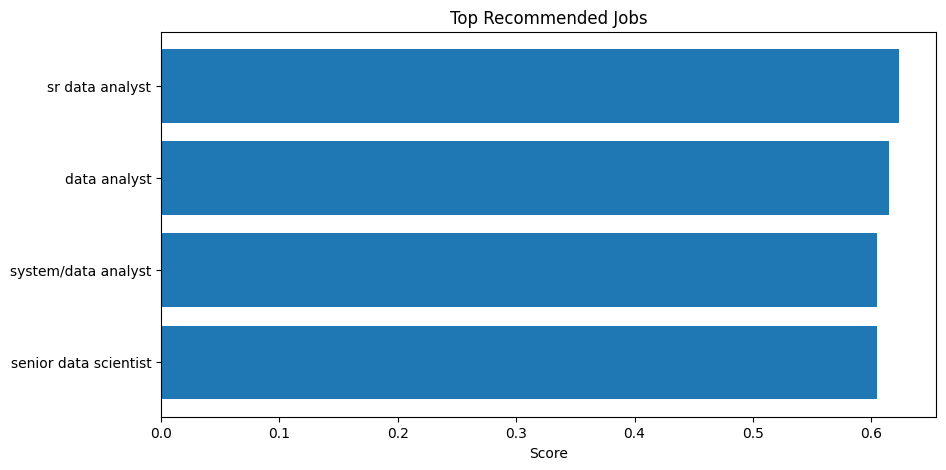

In [66]:
import matplotlib.pyplot as plt

scores = [
    score for idx, score in final_results[:5]
]

jobs = [
    jobs_data.iloc[idx]['job_title']
    for idx, score in final_results[:5]
]

plt.figure(figsize=(10,5))

plt.barh(jobs, scores)

plt.xlabel("Score")
plt.title("Top Recommended Jobs")

plt.gca().invert_yaxis()

plt.show()

In [68]:
final_df.to_csv(
    "final_job_recommendations.csv",
    index=False
)

print("Saved successfully")

Saved successfully
